In [2]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

In [3]:
def generate_triangle_Hamiltonian(num_qubits, J_list, J_parallel_list, phi_list=None):
    '''
    Single particle Hamiltonian

    use the gauge where all phase is on J_parallel
    '''

    if isinstance(J_list, (int, float)):
        J_list = [J_list]*(num_qubits-1)
    
    assert len(J_list) == num_qubits - 1, "J_list must have length num_qubits - 1"

    if isinstance(J_parallel_list, (int, float)):
        J_parallel_list = [J_parallel_list]*(num_qubits-2)

    assert len(J_parallel_list) == num_qubits - 2, "J_parallel_list must have length num_qubits - 2"

    if phi_list is None:
        phi_list = [0]*num_qubits
    if isinstance(phi_list, (int, float)):
        phi_list = [phi_list]*(num_qubits-2)

    assert len(phi_list) == num_qubits - 2, "phi_list must have length num_qubits - 2"



    H = np.zeros((num_qubits, num_qubits), dtype=complex)
    
    for i in range(num_qubits):
        if i < num_qubits - 1:
            H[i, i+1] = J_list[i]
            H[i+1, i] = np.conjugate(J_list[i])
        if i < num_qubits - 2:
            H[i,i+2] = J_parallel_list[0] * np.exp(1j * phi_list[i])
            H[i+2,i] = np.conjugate(J_parallel_list[0] * np.exp(1j * phi_list[i]))
    
    return H

# 1. 3 Qubits

In [4]:
num_qubits = 3

J_list = [-1]* (num_qubits - 1)
J_parallel_list = [-1] * (num_qubits - 2)

phi = np.pi
phi = 0

phi_list = [phi] * (num_qubits - 2)

H = generate_triangle_Hamiltonian(num_qubits, J_list, J_parallel_list, phi_list)

assert np.allclose(H, H.conj().T), "Hamiltonian is not Hermitian"

H.real

array([[ 0., -1., -1.],
       [-1.,  0., -1.],
       [-1., -1.,  0.]])

In [5]:
eigenvalues, eigenvectors = np.linalg.eigh(H)

sorted_indices = np.argsort(eigenvalues)
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

ground_state = eigenvectors[:,0]

print(np.round(eigenvalues,2))
print(list(eigenvectors[:,0]))
print(list(eigenvectors[:,1]))
print(list(eigenvectors[:,2]))


[-2.  1.  1.]
[(-0.5773502691896257+0j), (-0.5773502691896256+0j), (-0.5773502691896257+0j)]
[(0.4225033118769385+0j), (-0.8163286870591057+0j), (0.3938253751821674+0j)]
[(0.698682773595918+0j), (0.01655721447052927+0j), (-0.7152399880664473+0j)]


In [6]:
number_operators = []

for i in range(num_qubits):
    number_op = np.zeros((num_qubits, num_qubits), dtype=complex)
    number_op[i,i] = 1
    number_operators.append(number_op)

ground_state_populations = [(np.vdot(ground_state, op @ ground_state)).real for op in number_operators]
print(list(ground_state_populations))

[0.3333333333333333, 0.33333333333333315, 0.3333333333333333]


In [7]:
rung_current_operators = []

for i in range(num_qubits - 1):
    J = J_list[i]
    op = np.zeros((num_qubits, num_qubits), dtype=complex)
    op[i, i+1] = 1j * J
    op[i+1, i] = -1j * np.conjugate(J)
    rung_current_operators.append(op)

rung_currents = [(np.vdot(ground_state, op @ ground_state)).real for op in rung_current_operators]

print(list(np.round(rung_currents,2)))

leg_current_operators = []

for i in range(num_qubits - 2):
    J = J_list[i]
    op = np.zeros((num_qubits, num_qubits), dtype=complex)
    op[i, i+2] = -1j * J*np.exp(1j*phi_list[i])
    op[i+2, i] = 1j * np.conjugate(J*np.exp(1j*phi_list[i]))
    leg_current_operators.append(op)

leg_currents = [(np.vdot(ground_state, op @ ground_state)).real for op in leg_current_operators]

print(list(np.round(leg_currents,2)))


[0.0, 0.0]
[0.0]


In [8]:
plaquette_current_operator = np.zeros((num_qubits, num_qubits), dtype=complex)

plaquette_current_operator[0,1] = 1j * J_list[0]
plaquette_current_operator[1,0] = np.conjugate(1j * J_list[0])

plaquette_current_operator[1,2] = 1j * J_list[1]
plaquette_current_operator[2,1] = np.conjugate(1j * J_list[1])

plaquette_current_operator[2,0] = 1j * J_parallel_list[0] * np.exp(1j * phi_list[0])
plaquette_current_operator[0,2] = np.conjugate(1j * J_parallel_list[0] * np.exp(1j * phi_list[0]))


translation_operator = np.zeros((num_qubits, num_qubits), dtype=complex)

translation_operator[0,1] = J_list[0]
translation_operator[1,2] = J_list[1]
translation_operator[2,0] = J_parallel_list[0] * np.exp(-1j * phi_list[0])

# this does not extend well for more plaquettes because the translation operator no longer commutes with H

### 1.2 Degenerate ground state basis

In [9]:
v1 = eigenvectors[:,0]
v2 = eigenvectors[:,1]

j1 = rung_current_operators[0]
j2 = rung_current_operators[1]

print(np.vdot(v1, j1 @ v1))
print(np.vdot(v2, j1 @ v2))

0j
0j


In [10]:
# first vefity translation_operator and H commute
commutator = translation_operator @ H - H @ translation_operator
print(f'commutes: {np.allclose(commutator, np.zeros_like(commutator))}')
print(f'energy eigenvalues: {np.round(eigenvalues, 3)}')

# find momentum eigenstates
momentum_eigenvalues, momentum_eigenvectors = np.linalg.eig(translation_operator)

# find the two momentum states that span the degenerate ground state subspace
# print(momentum_eigenvalues)
# print(momentum_eigenvectors)
sorted_momentum_indices = np.argsort(momentum_eigenvalues)
momentum_eigenvalues = momentum_eigenvalues[sorted_momentum_indices]
momentum_eigenvectors = momentum_eigenvectors[:, sorted_momentum_indices]

print(f'momentum eigenvalues: {np.round(momentum_eigenvalues, 3)}')
print()



for i in range(len(momentum_eigenvalues)):
    momentum_state = momentum_eigenvectors[:, i]

    momentum_eigenvalue = momentum_eigenvalues[i]

    print(f'momentum eigenvalue: {momentum_eigenvalue}')
    print(f'momentum eigenvectors: {momentum_state}')
    print(f'\tkinectic part: {np.round(momentum_eigenvalue.real, 3)}')
    print(f'\tcurrent part: {np.round(momentum_eigenvalue.imag, 3)}')

    energy_eigenvalue = np.vdot(momentum_state, H @ momentum_state) / np.vdot(momentum_state, momentum_state)

    is_eigenstate = np.allclose(H @ momentum_state, energy_eigenvalue * momentum_state)
    if is_eigenstate:
        print(f"energy of momentum state: {np.round(energy_eigenvalue.real, 3)}")
    else:
        print(f'not an energy eigenstate, got energy: {np.round(energy_eigenvalue.real, 3)}')

    print()


### check matrix element of current states
# find all momentum eigenstates that have the lowest energy
lowest_energy = eigenvalues[0]
ground_state_momentum_indices = []

for i in range(len(momentum_eigenvalues)):
    momentum_state = momentum_eigenvectors[:, i]
    energy_eigenvalue = np.vdot(momentum_state, H @ momentum_state) / np.vdot(momentum_state, momentum_state)
    
    if np.allclose(energy_eigenvalue.real, lowest_energy):
        ground_state_momentum_indices.append(i)

print(f'Ground state momentum eigenstates at indices: {ground_state_momentum_indices}')
for idx in ground_state_momentum_indices:
    print(f'Momentum eigenvalue: {np.round(momentum_eigenvalues[idx], 3)}')

if len(ground_state_momentum_indices) == 2:
    idx1, idx2 = ground_state_momentum_indices
    state1 = momentum_eigenvectors[:, idx1]
    state2 = momentum_eigenvectors[:, idx2]
    matrix_element = np.vdot(state1, H @ state2)
    print(f"H matrix element between the two degenerate momentum eigenstates: {matrix_element}")




commutes: True
energy eigenvalues: [-2.  1.  1.]
momentum eigenvalues: [-1. -0.j     0.5+0.866j  0.5-0.866j]

momentum eigenvalue: (-1.0000000000000004-5.551115123125783e-17j)
momentum eigenvectors: [0.57735027+5.20417043e-17j 0.57735027-1.80411242e-16j
 0.57735027+0.00000000e+00j]
	kinectic part: -1.0
	current part: -0.0
energy of momentum state: -2.0

momentum eigenvalue: (0.5000000000000001+0.866025403784439j)
momentum eigenvectors: [-0.28867513+0.5j  0.57735027+0.j  -0.28867513-0.5j]
	kinectic part: 0.5
	current part: 0.866
energy of momentum state: 1.0

momentum eigenvalue: (0.5000000000000002-0.8660254037844389j)
momentum eigenvectors: [-0.28867513+0.5j -0.28867513-0.5j  0.57735027+0.j ]
	kinectic part: 0.5
	current part: -0.866
energy of momentum state: 1.0

Ground state momentum eigenstates at indices: [0]
Momentum eigenvalue: (-1-0j)


### 1.3 Single Rung Current
Defining the translation operator / plaquette current operator does not extend well with more plaquettes since they no longer commute with H. Another thing we can is assuming that in the pi flux case, if we measure a current (imag part of $a^\dagger a$) on a rung then it projects the whole state into the eigentate with that allowed current.

In [11]:
### print out all currents for each state

for i in range(len(eigenvalues)):
    eigenvector = eigenvectors[:,i]
    print(f'state with energy eigenvalue: {np.round(eigenvalues[i],2)}')
    print(f'\t<j_12>: {np.round(np.vdot(eigenvector, rung_current_operators[0] @ eigenvector).real, 2)}')
    print(f'\t<j_23>: {np.round(np.vdot(eigenvector, rung_current_operators[1] @ eigenvector).real, 2)}')
    print(f'\t<j_31>: {np.round(np.vdot(eigenvector, leg_current_operators[0] @ eigenvector).real, 2)}')
    print()

state with energy eigenvalue: -2.0
	<j_12>: 0.0
	<j_23>: 0.0
	<j_31>: 0.0

state with energy eigenvalue: 1.0
	<j_12>: 0.0
	<j_23>: 0.0
	<j_31>: 0.0

state with energy eigenvalue: 1.0
	<j_12>: 0.0
	<j_23>: 0.0
	<j_31>: 0.0



In [12]:
j_12 = rung_current_operators[0]



ground_state_current = np.vdot(ground_state, j_12 @ ground_state)

print(f'ground_state_current: {np.round(ground_state_current.real, 2)}')

j_12_eigenvalues, j_12_eigenvectors = np.linalg.eigh(j_12)

print(j_12_eigenvalues)
print(j_12_eigenvectors)

probabilities = []
current_sum = 0
print()
for i in range(len(j_12_eigenvalues)):
    j_12_eigenvector = j_12_eigenvectors[:,i]
    projector = np.outer(j_12_eigenvector, j_12_eigenvector.conj())
    projected_state = projector @ ground_state
    projection_amplitude = np.vdot(ground_state, projected_state)
    projection_probability = np.abs(projection_amplitude)
    probabilities.append(projection_probability)

    current_sum += projection_probability*j_12_eigenvalues[i]

    print(f'12 current eignvalues: {j_12_eigenvalues[i]}')
    print(f'projection probability: {projection_probability}')
    print()
print(current_sum)
print(sum(probabilities))

ground_state_current: 0.0
[-1.  0.  1.]
[[-0.70710678+0.j          0.        +0.j         -0.70710678+0.j        ]
 [ 0.        +0.70710678j  0.        +0.j          0.        -0.70710678j]
 [-0.        +0.j          1.        +0.j          0.        +0.j        ]]

12 current eignvalues: -1.0
projection probability: 0.33333333333333315

12 current eignvalues: 0.0
projection probability: 0.3333333333333333

12 current eignvalues: 1.0
projection probability: 0.33333333333333315

0.0
0.9999999999999997


So I originally thought that the pi flux ground states we easily written in terms of left an right rotating currents $\ket{L}$ and $\ket{R}$, but even these are not well definde in an extendable way since currents of adjacent rungs do not commute. For example with $\phi = \pi/2$, I expected the ground state to have 100% overlap with the +1 current eigenstate of $j_{12} = i(a_1^\dagger a_2 - a_2^\dagger a_1)$. This is not the case, instead it has overlap with all eigenstates (with eigenvalues -1,0,1). However, there is a well defined plaquette current defined as $j_{123} = j_{12}+j_{12}+j_{31}$. The ground state in this case is exactly one of the eigenstates of $j_{123}$ with a non zero current.

Next I will try projecting the states into plaquette current eigenstates

In [13]:
### store 3 qubit left and right states for later use

left_3 = [-0.28867513-0.5j,  0.28867513-0.5j,  0.57735027]
right_3 = [-0.28867513+0.5j,  0.28867513+0.5j,  0.57735027]

left_angles = np.angle(left_3)
right_angles = np.angle(right_3)

print(np.abs(left_3))

print(f'{left_angles}')
print(f'{right_angles}')

[0.57735027 0.57735027 0.57735027]
[-2.0943951  -1.04719756  0.        ]
[2.0943951  1.04719756 0.        ]


In [14]:
np.pi/3

1.0471975511965976

# 2. Infinite Lattice

In [15]:
# fourier transform definitions

def H_k(k, J, J_parallel, phi):
    '''
    Fourier transform of the Hamiltonian for the triangle lattice

    k: momentum
    J: nearest neighbor hopping
    J_parallel: next nearest neighbor hopping
    phi: flux through the plaquette
    '''
    H_k = np.zeros((2,2), dtype=complex)
    
    # nearest neighbor hopping
    H_k[0,1] = J * np.cos(k/2)
    H_k[1,0] = J * np.cos(k/2)
    
    # next nearest neighbor hopping with flux
    H_k[0,0] = J_parallel * np.cos(k - phi)
    H_k[1,1] = J_parallel * np.cos(k + phi)

    ###########

    H_k[0,1] = J * (1+np.exp(-1j*k))
    H_k[1,0] = J * (1+np.exp(1j*k))

    H_k[0,0] = J_parallel * 2 * np.cos(k - phi)
    H_k[1,1] = J_parallel * 2 * np.cos(k + phi)
    
    return H_k

def J_L(k, J, J_parallel, phi):
    '''
    Fourier transform of the Hamiltonian for the triangle lattice

    k: momentum
    J: nearest neighbor hopping
    J_parallel: next nearest neighbor hopping
    phi: flux through the plaquette
    '''
    J_L = np.zeros((2,2), dtype=complex)
    
    # nearest neighbor hopping
    J_L[0,1] = J * np.sin(k/2)
    J_L[1,0] = J * np.sin(k/2)
    
    # next nearest neighbor hopping with flux
    J_L[0,0] = J_parallel * np.sin(k - phi)
    J_L[1,1] = J_parallel * np.sin(k + phi)


    ###########

    J_L[0,1] = J * 1j*(1-np.exp(-1j*k))
    J_L[1,0] = J * (-1j)*(1-np.exp(1j*k))

    J_L[0,0] = J_parallel * 2 * np.sin(k - phi)
    J_L[1,1] = J_parallel * 2 * np.sin(k + phi)
    
    return J_L


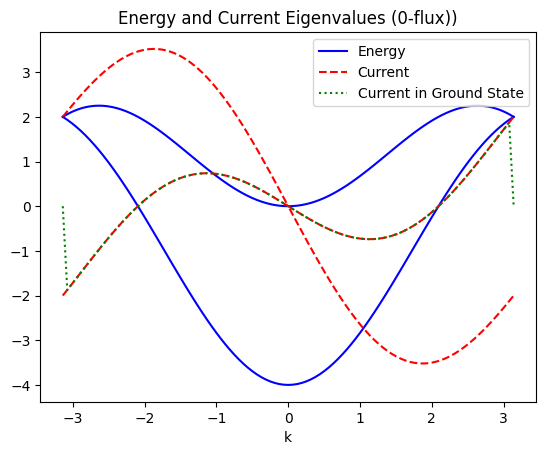

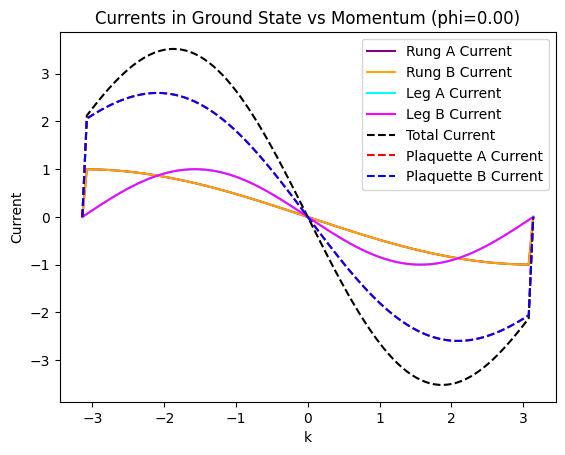

[-1.9999999999999996, -1.8734320816728358, -1.7453869897279337, -1.6163613000347112, -1.4868496282992463, -1.3573426924403802, -1.228325396088021, -1.1002749407473482, -0.9736589740538313, -0.8489337813958922, -0.7265425280053606, -0.6069135584110713, -0.4904587599191248, -0.3775719965251394, -0.26862761938045965, -0.16397905962684056, -0.0639575090836969, 0.031129306079840213, 0.12099825392800889, 0.20539182322737903, 0.2840790438404117, 0.35685629750588177, 0.42354801590579905, 0.484007263368036, 0.5381162020137201, 0.5857864376269055, 0.6269592449991658, 0.6616056719816515, 0.6897265219599981, 0.7113522149513096, 0.726542528005361, 0.7353862160722422, 0.7380005149740458, 0.7345305285869852, 0.7251485028005993, 0.7100529892708012, 0.6894679024214336, 0.6636414735732622, 0.6328451064880212, 0.5973721390067963, 0.5575365158350514, 0.5136713778795348, 0.4661275738737206, 0.4152721003370602, 0.3614864761979062, 0.30516505866943255, 0.24671330720110085, 0.1865460025344205, 0.1250854280699

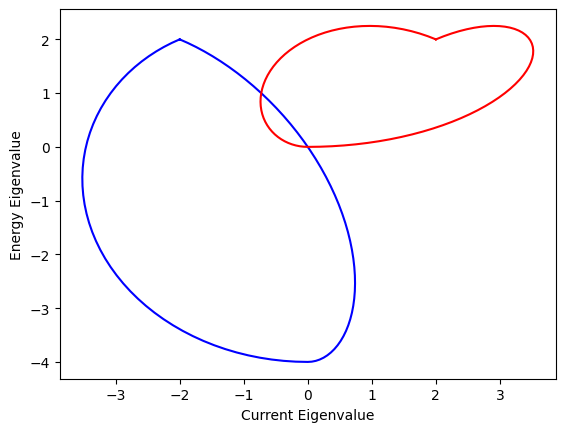

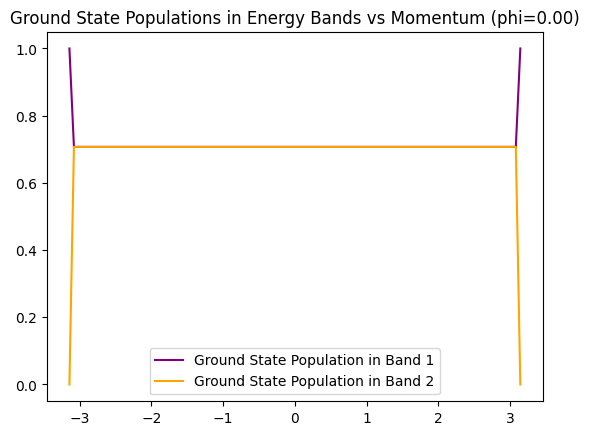

In [24]:
phi = np.pi
# phi = np.pi
phi = 0

J = -1
J_parallel = -1

ks = np.linspace(-np.pi, np.pi, 101)

energy_eigenvalues_1 = []
energy_eigenvalues_2 = []

current_eigenvalues_1 = []
current_eigenvalues_2 = []

currents_rung_A = []
currents_rung_B = []
currents_leg_A = []
currents_leg_B = []




current_values = []

ground_state_populations = np.zeros((2, len(ks)))

for i in range(len(ks)):
    k = ks[i]
    H_k_matrix = H_k(k, J, J_parallel, phi)
    J_L_matrix = J_L(k, J, J_parallel, phi)

    commutes = np.allclose(H_k_matrix @ J_L_matrix - J_L_matrix @ H_k_matrix, np.zeros_like(H_k_matrix))
    # print(f'k: {k:.2f}, commutes: {commutes}')

    
    energy_eigenvalues, energy_eigenvectors = np.linalg.eigh(H_k_matrix)
    current_eigenvalues, current_eigenvectors = np.linalg.eigh(J_L_matrix)

    sorted_energy_indices = np.argsort(energy_eigenvalues)
    energy_eigenvalues = energy_eigenvalues[sorted_energy_indices]
    energy_eigenvectors = energy_eigenvectors[:, sorted_energy_indices]

    energy_eigenvalues_1.append(energy_eigenvalues[0])
    energy_eigenvalues_2.append(energy_eigenvalues[1])

    current_eigenvalues_1.append(current_eigenvalues[0])
    current_eigenvalues_2.append(current_eigenvalues[1])

    # calculate individual edge currents
    alpha, beta = energy_eigenvectors[:,0]

    current_rung_A = 2*J * np.imag(np.conjugate(alpha)*beta)
    current_rung_B = 2*J * np.imag(np.conjugate(beta)*alpha*np.exp(1j*k))
    current_leg_A = 2*J_parallel * np.sin(k - phi) * np.abs(alpha)**2
    current_leg_B = 2*J_parallel * np.sin(k + phi) * np.abs(beta)**2

    currents_rung_A.append(current_rung_A)
    currents_rung_B.append(current_rung_B)
    currents_leg_A.append(current_leg_A)
    currents_leg_B.append(current_leg_B)

    # find eigenvector of H from lowest energy band
    ground_state = energy_eigenvectors[:,0]

    # print(f'ground state population: {np.abs(ground_state)}')
    ground_state_populations[:, i] = np.abs(ground_state)

    current = np.vdot(ground_state, J_L_matrix @ ground_state)
    current_values.append(current)

    if not commutes:
        print(f'index {i} does not commute')



current_rung_A = np.array(currents_rung_A)
current_rung_B = np.array(currents_rung_B)
current_leg_A = np.array(currents_leg_A)
current_leg_B = np.array(currents_leg_B)

plaquette_current_A = current_rung_A + current_leg_A + current_rung_B
plaquette_current_B = current_rung_B + current_leg_B + current_rung_A
unit_cell_current = current_rung_A + current_rung_B + current_leg_A + current_leg_B
        
    

plt.plot(ks, energy_eigenvalues_1, color='blue')
plt.plot(ks, energy_eigenvalues_2, color='blue', label='Energy')

plt.plot(ks, current_eigenvalues_1, color='red', linestyle='dashed')
plt.plot(ks, current_eigenvalues_2, color='red', linestyle='dashed', label='Current')

plt.plot(ks, current_values, color='green', linestyle='dotted', label='Current in Ground State')

plt.xlabel('k')
plt.legend()
plt.title(f'Energy and Current Eigenvalues (0-flux))')
# plt.title(f'Energy and Current Eigenvalues ($\pi$-flux))')
plt.show()

plt.plot(ks, currents_rung_A, color='purple', label='Rung A Current')
plt.plot(ks, currents_rung_B, color='orange', label='Rung B Current')
plt.plot(ks, currents_leg_A, color='cyan', label='Leg A Current')
plt.plot(ks, currents_leg_B, color='magenta', label='Leg B Current')
plt.plot(ks, unit_cell_current, color='black', linestyle='dashed', label='Total Current')
plt.plot(ks, plaquette_current_A, color='red', linestyle='dashed', label='Plaquette A Current')
plt.plot(ks, plaquette_current_B, color='blue', linestyle='dashed', label='Plaquette B Current')
plt.xlabel('k')
plt.ylabel('Current')
plt.legend()
plt.title(f'Currents in Ground State vs Momentum (phi={phi:.2f})')
plt.show()

print(current_eigenvalues_1)
plt.plot(current_eigenvalues_1, energy_eigenvalues_1, color='blue', label='Band 1')
plt.plot(current_eigenvalues_2, energy_eigenvalues_2, color='red', label='Band 2')
plt.xlabel('Current Eigenvalue')
plt.ylabel('Energy Eigenvalue')
plt.show()
plt.show()


plt.plot(ks, ground_state_populations[0,:], color='purple', label='Ground State Population in Band 1')
plt.plot(ks, ground_state_populations[1,:], color='orange', label='Ground State Population in Band 2')
plt.legend()
plt.title(f'Ground State Populations in Energy Bands vs Momentum (phi={phi:.2f})')
plt.show()

    # print(f'k: {k:.2f}, H_k: {H_k_matrix}, J_L: {J_L_matrix}')

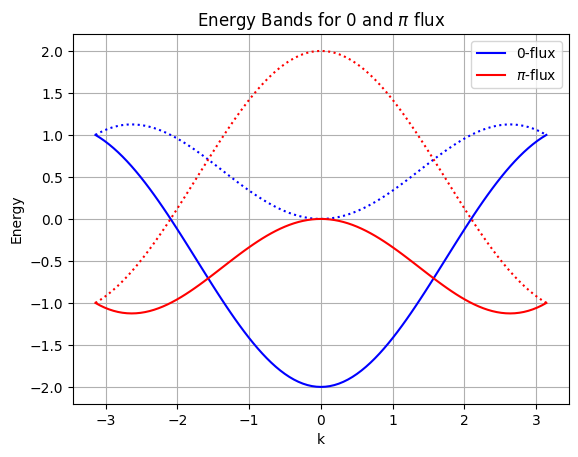

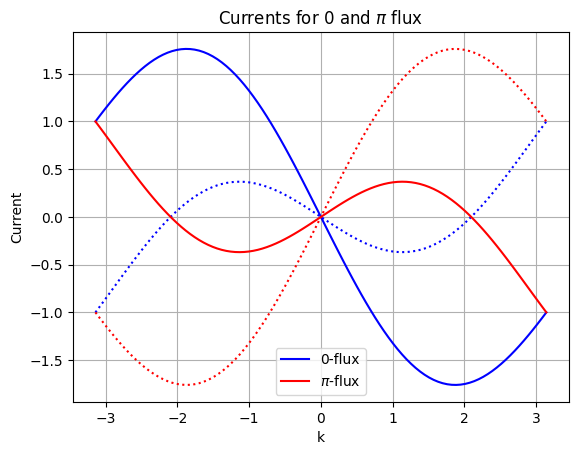

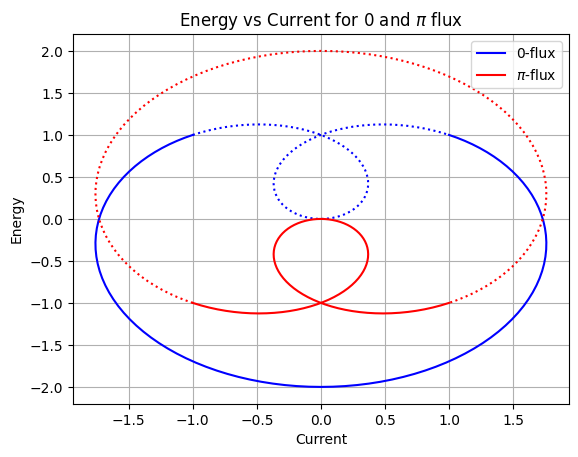

In [38]:
energy_flux_0_plus = lambda k: -np.cos(k) + np.cos(k/2)
energy_flux_0_minus = lambda k: -np.cos(k) - np.cos(k/2)

energy_flux_pi_plus = lambda k: np.cos(k) + np.cos(k/2)
energy_flux_pi_minus = lambda k: np.cos(k) - np.cos(k/2)

current_flux_0_plus = lambda k: -np.sin(k) + np.sin(k/2)
current_flux_0_minus = lambda k: -np.sin(k) - np.sin(k/2)

current_flux_pi_plus = lambda k: np.sin(k) + np.sin(k/2)
current_flux_pi_minus = lambda k: np.sin(k) - np.sin(k/2)


plt.plot(ks, energy_flux_0_minus(ks), color='blue', label='0-flux')
plt.plot(ks, energy_flux_0_plus(ks), color='blue', linestyle='dotted')

plt.plot(ks, energy_flux_pi_minus(ks), color='red', label='$\pi$-flux')
plt.plot(ks, energy_flux_pi_plus(ks), color='red', linestyle='dotted')

plt.xlabel('k')
plt.ylabel('Energy')

plt.legend()
plt.grid()
plt.title('Energy Bands for 0 and $\pi$ flux')
plt.show()

plt.plot(ks, current_flux_0_minus(ks), color='blue', label='0-flux')
plt.plot(ks, current_flux_0_plus(ks), color='blue', linestyle='dotted')

plt.plot(ks, current_flux_pi_minus(ks), color='red', label='$\pi$-flux')
plt.plot(ks, current_flux_pi_plus(ks), color='red', linestyle='dotted')

plt.xlabel('k')
plt.ylabel('Current')

plt.legend()
plt.grid()
plt.title('Currents for 0 and $\pi$ flux')
plt.show()


plt.plot(current_flux_0_minus(ks), energy_flux_0_minus(ks), color='blue', label='0-flux')
plt.plot(current_flux_0_plus(ks), energy_flux_0_plus(ks), color='blue', linestyle='dotted')

plt.plot(current_flux_pi_minus(ks), energy_flux_pi_minus(ks), color='red', label='$\pi$-flux')
plt.plot(current_flux_pi_plus(ks), energy_flux_pi_plus(ks), color='red', linestyle='dotted')

plt.xlabel('Current')
plt.ylabel('Energy')

plt.legend()
plt.grid()
plt.title('Energy vs Current for 0 and $\pi$ flux')
plt.show()

In [17]:
alpha = 1j
beta = (2+10j)

print(np.conjugate(alpha)*beta - np.conjugate(beta)*alpha)

-4j


# 3. Finite Plaquettes


In [18]:
num_qubits = 50

J_list = [-1]* (num_qubits - 1)
J_parallel_list = [-1] * (num_qubits - 2)

phi = np.pi/2
phi = 0

phi_list = [phi] * (num_qubits - 2)

H = generate_triangle_Hamiltonian(num_qubits, J_list, J_parallel_list, phi_list)

assert np.allclose(H, H.conj().T), "Hamiltonian is not Hermitian"

H.real

array([[ 0., -1., -1., ...,  0.,  0.,  0.],
       [-1.,  0., -1., ...,  0.,  0.,  0.],
       [-1., -1.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  0., -1., -1.],
       [ 0.,  0.,  0., ..., -1.,  0., -1.],
       [ 0.,  0.,  0., ..., -1., -1.,  0.]])

In [19]:
eigenvalues, eigenvectors = np.linalg.eigh(H)

sorted_indices = np.argsort(eigenvalues)
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

ground_state = eigenvectors[:,0]

In [20]:
number_operators = []

for i in range(num_qubits):
    number_op = np.zeros((num_qubits, num_qubits), dtype=complex)
    number_op[i,i] = 1
    number_operators.append(number_op)

ground_state_populations = [(np.vdot(ground_state, op @ ground_state)).real for op in number_operators]
print(list(ground_state_populations))

[0.00027484222717444974, 0.0007156845558281678, 0.0015408519150155967, 0.0025685504552331695, 0.0038781942384315564, 0.005402591677374428, 0.007141709078082624, 0.009059483350350351, 0.011131994412651473, 0.013326536094573243, 0.015611383691805291, 0.01795229047458613, 0.020314672350887148, 0.02266342214657583, 0.024963718750485583, 0.027181425801022147, 0.029283645977417613, 0.031239189764999398, 0.033019045902210574, 0.03459680870439272, 0.03594907103135867, 0.03705577106764092, 0.0379004901428729, 0.038470696240608594, 0.038757929948424745, 0.03875792994842455, 0.038470696240608136, 0.037900490142872244, 0.037055771067640145, 0.0359490710313578, 0.034596808704391954, 0.033019045902209866, 0.031239189764998797, 0.0292836459774171, 0.027181425801021772, 0.02496371875048518, 0.022663422146575553, 0.02031467235088695, 0.017952290474585988, 0.015611383691805194, 0.013326536094573191, 0.011131994412651497, 0.009059483350350455, 0.007141709078082704, 0.005402591677374496, 0.003878194238431

In [21]:
rung_current_operators = []

for i in range(num_qubits - 1):
    J = J_list[i]
    op = np.zeros((num_qubits, num_qubits), dtype=complex)
    op[i, i+1] = 1j * J
    op[i+1, i] = -1j * np.conjugate(J)
    rung_current_operators.append(op)

rung_currents = [(np.vdot(ground_state, op @ ground_state)).real for op in rung_current_operators]

print(list(np.round(rung_currents,2)))

leg_current_operators = []

for i in range(num_qubits - 2):
    J = J_list[i]
    op = np.zeros((num_qubits, num_qubits), dtype=complex)
    op[i, i+2] = -1j * J*np.exp(1j*phi_list[i])
    op[i+2, i] = 1j * np.conjugate(J*np.exp(1j*phi_list[i]))
    leg_current_operators.append(op)

leg_currents = [(np.vdot(ground_state, op @ ground_state)).real for op in leg_current_operators]

print(list(np.round(leg_currents,2)))


[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [22]:
plaquette_current_operators = []

for i in range(num_qubits-2):
    plaquette_current_operator = 0
    plaquette_current_operator += rung_current_operators[i]
    plaquette_current_operator += rung_current_operators[i+1]
    plaquette_current_operator += leg_current_operators[i]

    plaquette_current_operators.append(plaquette_current_operator)



In [23]:

left_6 = 1/np.sqrt(6)*np.array([
    np.exp(1j * -2 * np.pi/3),
    np.exp(1j * -1 * np.pi/3),
    np.exp(1j * 0 * np.pi/3),
    np.exp(1j * 1 * np.pi/3),
    np.exp(1j * 2 * np.pi/3),
    np.exp(1j * 3 * np.pi/3),
    ])

right_6 = 1/np.sqrt(6)*np.array([
    np.exp(-1j * -2 * np.pi/3),
    np.exp(-1j * -1 * np.pi/3),
    np.exp(-1j * 0 * np.pi/3),
    np.exp(-1j * 1 * np.pi/3),
    np.exp(-1j * 2 * np.pi/3),
    np.exp(-1j * 3 * np.pi/3),
    ])

ground_state_manual = 1/np.sqrt(2) * (left_6 + right_6)

print(np.vdot(ground_state_manual, ground_state))


ValueError: cannot reshape array of size 50 into shape (6,)

In [ ]:
### analyze ground state

print(np.sum(np.abs(ground_state_manual - ground_state)))

print(list(ground_state))
print(list(np.power(np.abs(ground_state),2)))

2.9793728525716245
[(-0.28582823953151365+0j), (-0.4061809686249346+0j), (-0.5033082934079522+0j), (-0.5033082934079525+0j), (-0.40618096862493525+0j), (-0.285828239531514+0j)]
[0.08169778251368434, 0.16498297927309008, 0.25331923821322533, 0.25331923821322555, 0.16498297927309064, 0.08169778251368454]


In [ ]:
### find plaquette eigenvalues and eigenstates

for i in range(len(plaquette_current_operators)):
    
    print(f'plaquette {i+1} with sites {i+1, i+2, i+3}')
    plaquette_current_operator = plaquette_current_operators[i]
    plaquette_eigenvalues, plaquette_eigenvectors = np.linalg.eigh(plaquette_current_operator)

    for j in range(len(plaquette_eigenvalues)):
        plaquette_eigenvalue = plaquette_eigenvalues[j]
        plaquette_eigenvector = plaquette_eigenvectors[j]
        print(f'\tplaquette eigenstate with eigenvalue: {plaquette_eigenvalue}')

        projector = np.outer(plaquette_eigenvector, plaquette_eigenvector.conj())

        projected_state = projector @ ground_state
        projection_amplitude = np.vdot(ground_state, projected_state)
        projection_probability = np.abs(projection_amplitude)

        print(f'\t\tprojection_probability: {projection_probability}')
    print()
    
    break

plaquette 1 with sites (1, 2, 3)
	plaquette eigenstate with eigenvalue: -1.7320508075688772
		projection_probability: 0.3187220247003027
	plaquette eigenstate with eigenvalue: -8.673617379884035e-17
		projection_probability: 0.004828259800078108
	plaquette eigenstate with eigenvalue: 0.0
		projection_probability: 0.00482825980007812
	plaquette eigenstate with eigenvalue: 0.0
		projection_probability: 0.25331923821322533
	plaquette eigenstate with eigenvalue: 0.0
		projection_probability: 0.25331923821322555
	plaquette eigenstate with eigenvalue: 1.7320508075688776
		projection_probability: 0.16498297927309064

